In [ ]:
##install the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline

In [ ]:
df= pd.read_csv('/content/lap data set csv file.csv')
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [ ]:
df.shape

(4269, 13)

In [ ]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


<Axes: >

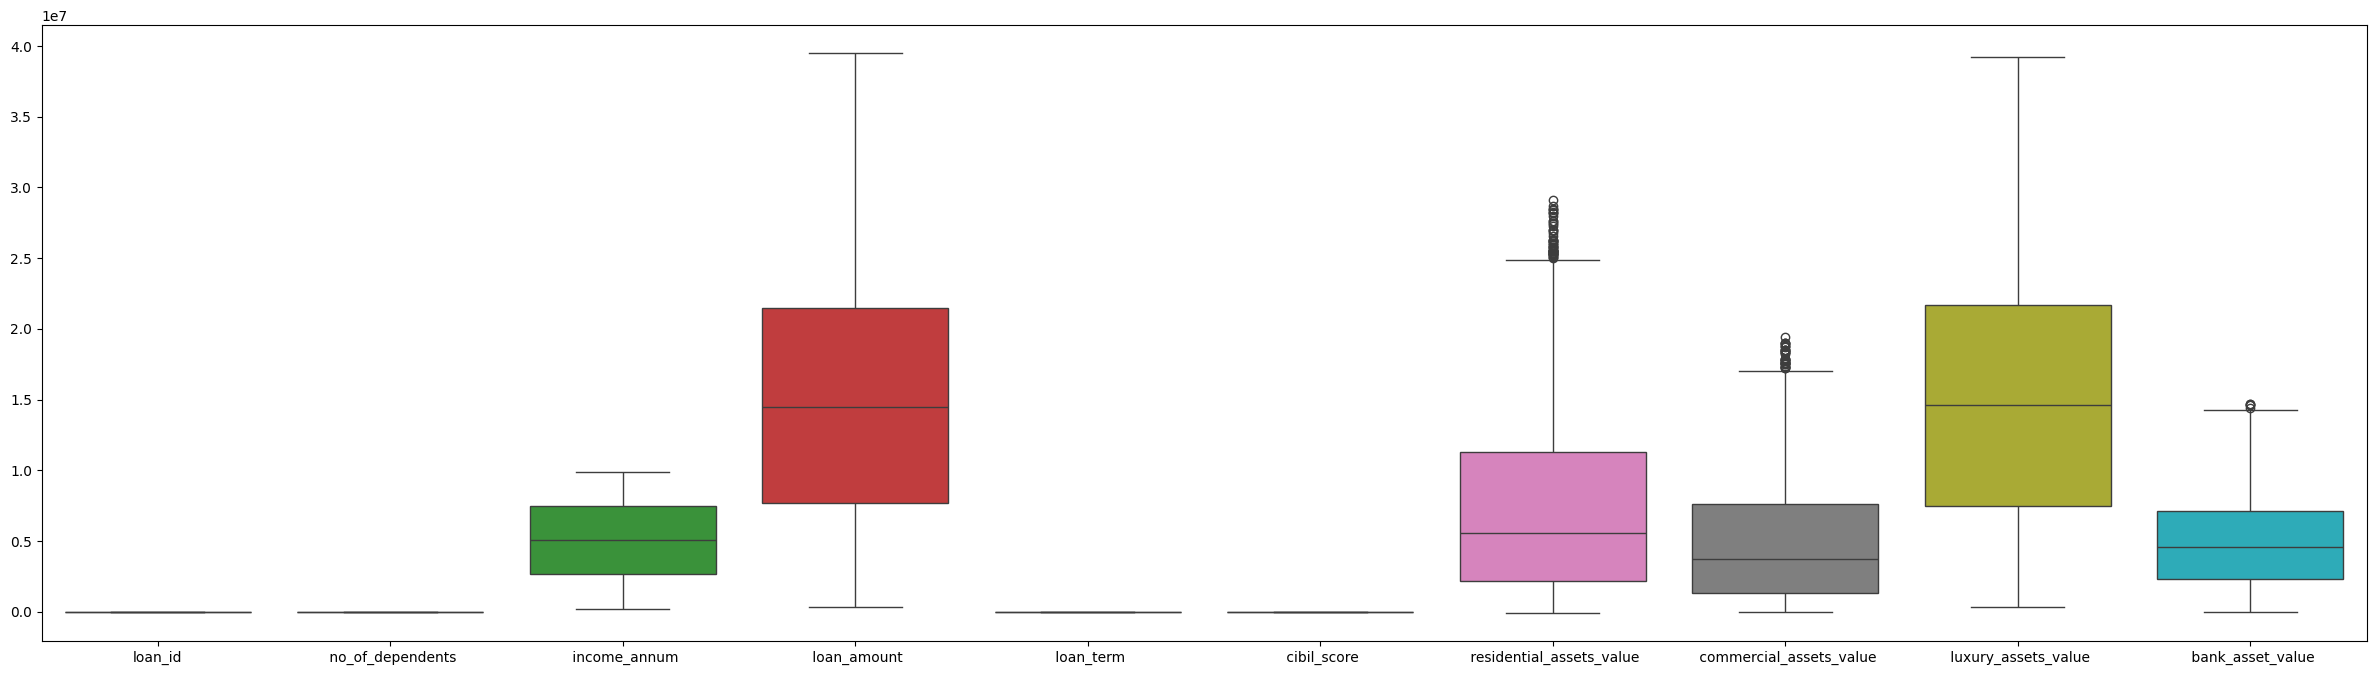

In [ ]:
## checking the outliers
plt.figure(figsize=(30,8))
sns.boxplot(data =df)

In [ ]:
## filling null values in data type
df[' loan_amount']=df[' loan_amount'].fillna(df[' loan_amount'].median())

In [ ]:
df[' loan_amount'].median()

14500000.0

In [ ]:
df[' loan_amount'].mean()

np.float64(15133450.456781447)

Number of people who took loan by education
 education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64


<Axes: xlabel=' education', ylabel='count'>

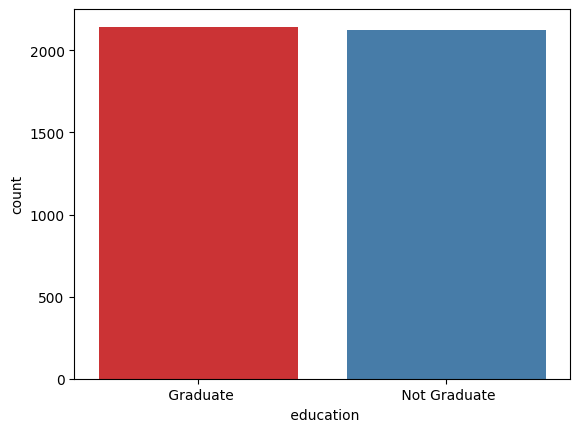

In [ ]:
print('Number of people who took loan by education')
print(df[' education'].value_counts())
sns.countplot(x=' education',data = df, palette='Set1')

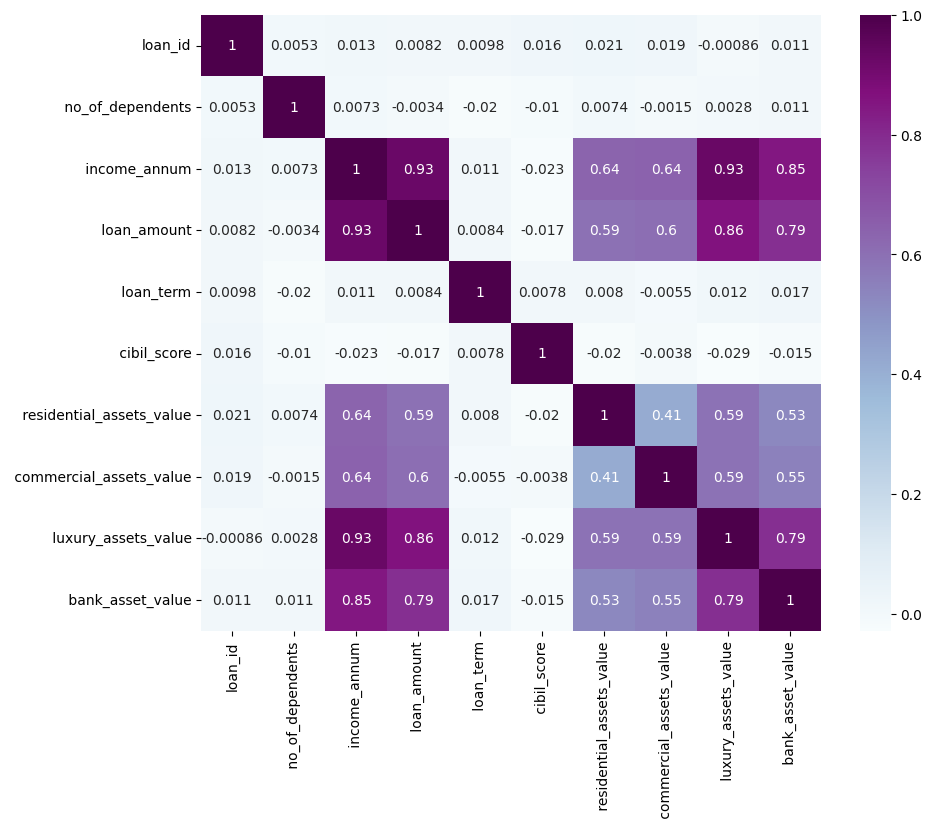

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='BuPu')
plt.show()

In [ ]:
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()



In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

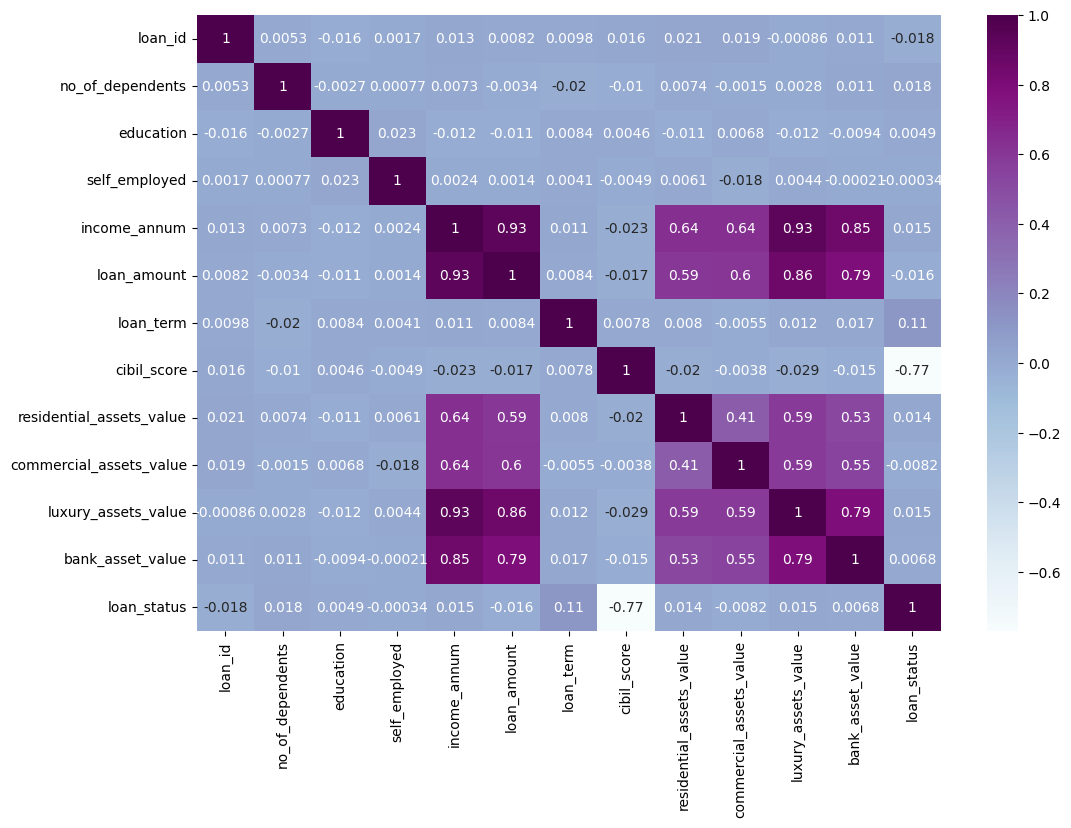

In [ ]:
corr = df_encoded.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='BuPu')
plt.show()

In [ ]:
## Total Applicant Income

df[' Total_Income'] = df['income_annum']

<Axes: xlabel='income_annum', ylabel='Density'>

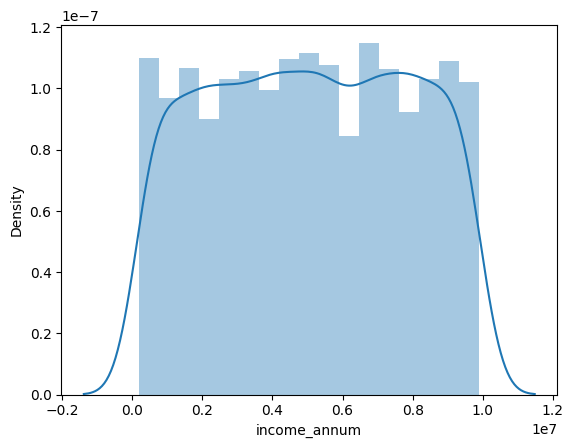

In [ ]:
## Apply Log Transformation

df[['income_annum', 'income_annum']].head()
sns.distplot(df['income_annum'])

<Axes: xlabel='loan_amount', ylabel='Density'>

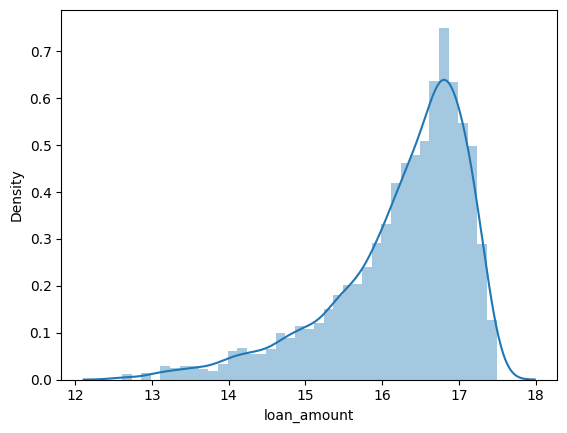

In [ ]:
df['loan_amount'] = np.log(df['loan_amount'] + 1)
sns.distplot(df['loan_amount'])

<Axes: xlabel='loan_term', ylabel='Density'>

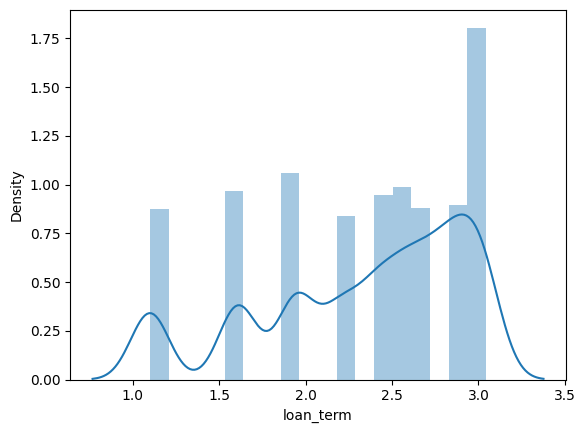

In [ ]:
df['loan_term'] = np.log(df['loan_term'] + 1)
sns.distplot(df['loan_term'])

In [ ]:
## Encoding Technique : Label Encoding, One Hot Encoding

from sklearn.preprocessing import LabelEncoder
cols = ['education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status']
le =  LabelEncoder()
for col in cols:
  df[col] =  le.fit_transform(df[col])

In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,Total_Income
0,1,2,0,0,94,296,5,478,25,175,224,80,0,9600000
1,2,0,1,1,39,119,3,117,28,22,85,33,1,4100000
2,3,3,0,0,89,294,9,206,72,45,330,127,1,9100000
3,4,3,0,0,80,304,3,167,183,33,230,79,1,8200000
4,5,5,1,1,96,239,9,82,125,82,291,50,1,9800000


In [ ]:
df.dtypes

,0
loan_id,int64
no_of_dependents,int64
education,int64
self_employed,int64
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64


In [ ]:
## Split Independent and dependent features

X = df.drop(columns = ['loan_status'],axis = 1)
y = df['loan_status']

In [ ]:
X

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,Total_Income
0,1,2,0,0,94,296,5,478,25,175,224,80,9600000
1,2,0,1,1,39,119,3,117,28,22,85,33,4100000
2,3,3,0,0,89,294,9,206,72,45,330,127,9100000
3,4,3,0,0,80,304,3,167,183,33,230,79,8200000
4,5,5,1,1,96,239,9,82,125,82,291,50,9800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,0,1,8,20,5,17,29,5,30,8,1000000
4265,4266,0,1,1,31,110,9,259,43,29,107,19,3300000
4266,4267,2,1,0,63,236,8,157,13,124,178,73,6500000
4267,4268,1,1,0,39,125,3,480,83,7,138,58,4100000


In [ ]:
y

,loan_status
0,0
1,1
2,1
3,1
4,1
...,...
4264,1
4265,0
4266,1
4267,0


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.25,random_state = 42)


In [ ]:
## Logistic Regression
model1 = LogisticRegression()
model1.fit(X_train,y_train)
y_pred_model1 = model1.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_model1)

In [ ]:
## Accuracy : the ratio of the correctly predicted values to total values
accuracy*100

83.33333333333334

In [ ]:
score = cross_val_score(model1,X,y,cv=5)
score

array([0.764637  , 0.81498829, 0.85831382, 0.86651054, 0.84290739])

In [ ]:
np.mean(score)*100

np.float64(82.94714068818963)

In [ ]:
## Decision Tree Classifier

model2 = DecisionTreeClassifier()
model2.fit(X_train,y_train)
y_pred_model2 = model2.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_model2)
print("Accuracy score of Decision Tree: ", accuracy*100)

Accuracy score of Decision Tree:  98.22097378277154


In [ ]:
score = cross_val_score(model2,X,y,cv=5)
print("Cross Validation score of Decision Tree: ",np.mean(score)*100)

Cross Validation score of Decision Tree:  97.35288868877167


In [ ]:
from sklearn.metrics import classification_report

def generate_classification_report(model_name,y_test,y_pred):
  report = classification_report(y_test,y_pred)
  print(f"Classification Report For {model_name}:\n{report}\n")

generate_classification_report(model1,y_test,y_pred_model1)
generate_classification_report(model2,y_test,y_pred_model2)


Classification Report For LogisticRegression():
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       678
           1       0.82      0.70      0.75       390

    accuracy                           0.83      1068
   macro avg       0.83      0.81      0.81      1068
weighted avg       0.83      0.83      0.83      1068


Classification Report For DecisionTreeClassifier():
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       678
           1       0.98      0.97      0.98       390

    accuracy                           0.98      1068
   macro avg       0.98      0.98      0.98      1068
weighted avg       0.98      0.98      0.98      1068




In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
0,2656
1,1613


In [ ]:
pip install -U imbalanced-learn

In [ ]:
from imblearn.over_sampling import RandomOverSampler

In [ ]:
oversample = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversample.fit_resample(X,y)

df_resampled = pd.concat([pd.DataFrame(X_resampled,columns=X.columns),pd.Series(y_resampled,name="Loan_status")],axis=1)

In [ ]:
X_resampled


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,Total_Income
0,1,2,0,0,94,296,5,478,25,175,224,80,9600000
1,2,0,1,1,39,119,3,117,28,22,85,33,4100000
2,3,3,0,0,89,294,9,206,72,45,330,127,9100000
3,4,3,0,0,80,304,3,167,183,33,230,79,8200000
4,5,5,1,1,96,239,9,82,125,82,291,50,9800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5307,71,4,1,1,3,12,9,40,2,2,16,6,500000
5308,1640,3,0,1,30,96,4,16,92,55,85,36,3200000
5309,3637,0,0,0,64,149,8,197,16,69,142,93,6600000
5310,1951,0,0,1,0,4,4,287,0,1,2,1,200000


In [ ]:
y_resampled


,loan_status
0,0
1,1
2,1
3,1
4,1
...,...
5307,1
5308,1
5309,1
5310,1


In [ ]:
y_resampled.value_counts()

,count
loan_status,
0,2656
1,2656


In [ ]:
X_resampled_train, X_resampled_test, y_resampled_train, y_resampled_test = train_test_split(X_resampled,y_resampled,test_size = 0.25,random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
## Logistic Regression
model1 = LogisticRegression()
model1.fit(X_resampled_train,y_resampled_train)
y_pred_model1 = model1.predict(X_resampled_test)
accuracy = accuracy_score(y_resampled_test,y_pred_model1)
accuracy*100

81.77710843373494

In [ ]:
## Random Forest Classifier
model3 = RandomForestClassifier()
model3.fit(X_resampled_train,y_resampled_train)
y_pred_model3 = model3.predict(X_resampled_test)
accuracy = accuracy_score(y_resampled_test,y_pred_model3)
print("Accuracy score of Random Forest: ", accuracy*100)

Accuracy score of Random Forest:  98.26807228915662


In [ ]:
from sklearn.metrics import classification_report

def generate_classification_report(model_name,y_test,y_pred):
  report = classification_report(y_test,y_pred)
  print(f"Classification Report For {model_name}:\n{report}\n")

generate_classification_report(model1,y_resampled_test,y_pred_model1)


Classification Report For LogisticRegression():
              precision    recall  f1-score   support

           0       0.77      0.89      0.82       639
           1       0.88      0.75      0.81       689

    accuracy                           0.82      1328
   macro avg       0.82      0.82      0.82      1328
weighted avg       0.83      0.82      0.82      1328




LOAN APPROVAL PREDICTION MODEL DONE USING LOGISTIC REGRESION AND DECISION TREE CLASSIFIER